# Assignment 4 $-$ Argument Generation
_Solutions have to be submitted in pairs of two by Monday, July 13th, 23:59 (UTC+2)._

**Grading:**

This assignment is worth 30 points, which you earn through running code without unhandled, preventable errors, correct outputs, and answers to analysis questions
- **0 - *Fail*:** No submission; non-working code (preventable errors and exceptions); code that directly contradicts the task description or produces incorrect outputs; authorship violations like plagiarism or solutions fully or largely generated by AI

**Submission Components:**

- **Code:** Tasks 1 and 2
  - **Output Files:** Your submission should include the output files in the correct folder with the correct naming.
  - **Explanation:** You should add overall explanations of your code (i.e., modify/employ docstrings) and comments for individual implementation decisions.
- **Analysis:** Task 3 answered in full text with sensible formatting and using the results from task 2 explicitly.

**Submission Group:**

YOUR ANSWER HERE
1. Name 
2. Name 


In [ ]:
# While you do not train the LLM, generation is still faster on GPU, and
# you might need GPU access for any of your evaluation metrics in task 1:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU is available:", torch.cuda.is_available())

## Assignment Overview

### Learning Goals
- Exploring inherent capabilities of LLMs for argument improvement
- Getting acquainted with prompt engineering
     - Zero-shot prompting
     - Few-shot prompting and few-shot selection
     - Different prompting strategies
    
### Topics Covered
- Prompting strategies
- Automated evaluation for generation
- Ethics of LLM use in Computational Argumentation

  
### General Description

**Main Task: LLM-Rewriting** Given data annotated for inappropriateness and the underlying problems, prompt _Llama-3.1-8B_ and _Llama-3.1-8B-Instruct_ with different strategies and compare each strategy’s performance.
- Baseline Explore zero-shot prompting
- Few-shot Explore few-shot prompting and example selection for few-shots
- Further Strategies Explore strategies like persona prompting, providing further context, or combining strategies.

**Auxiliary Task: Evaluation** Given a small amount of parallel training data, but no parallel test data (no gold rewrites), analyze the rewriting performance.
- Metrics Measure the success of keeping the original content while removing inappropriateness without parallel data

## Introduction

### Motivation

- Heated or emotional discussions produce confusing or fallacious arguments
- Inappropriate style may compromise arguments with otherwise valid points
- Toxicity (emotional/ad-hominem attacks) harms other participants

$\to$ Improve arguments by rewriting inappropriate style 


### Appropriateness Mitigation

Consider the above examples, first on their own, then in conjunction with their rewrites, and lastly in the light of the given taxonomy:
1. What is inappropriate about the arguments, and how could this be remedied without changing the core claims? 
2. How do the taxonomy-based highlights reflect the issues you found?
3. Do the rewrites catch all issues of the instances? Was something changed or removed that distorts the argument's interpretation?

| | **Argument** | **Rewrite** |
| -- | :-- | :-- |
| 1 | <span style="color:gray">[Issue: news reporters should go to jail for what they write]</span> |  |
| | <span style="background-color: #a893e4">You have all missed the point.</span> <span style="background-color: #f4ac7c">Confidential sources within the Government that leak classified information are not covered by the freedom of the press.</span> When a court order is issued there is more at stake than a news story. Often the court order compromises one case to resolve another. When you have someone that leaks vital information that threatens the welfare of the American People (nuclear secrets etc) you might give up a case against a <span style="background-color: #e398ba">squealer</span> to get the name of the <span style="background-color: #e398ba">mole</span>. <span style="background-color: #f4ac7c">Freedom of the press means you can publish what you want. It doesn‘t mean that you are free of the consequences.</span> Geraldo got thrown out of Iraq for airing the American battle plans for Bagdad before the battle. <span style="background-color: #e398ba">He shoulda been hung.</span> | When a court order is issued, there is more at stake than a news story. Often, the court order compromises one case to resolve another. While freedom of the press allows journalists to publish information without fear of government interference, it does not mean that they are free from legal or other consequences. Geraldo was ultimately expelled from Iraq for airing the American battle plans for Baghdad before the battle. |
| 2 | <span style="color:gray">[Issue: pro-live vs. pro-choice]</span> |  |
| | for everyone who is talking about <span style="background-color: #e398ba">RAPE</span> in this subject let me ask you one thing<span style="background-color: #e398ba">!!!!</span> <span style="background-color: #f4ac7c">if you got in a huge fight with someone and ended up breaking your hand or arm... would you cut it off just because it would <span style="background-color: #e398ba">REMIND</span> you of that expirience</span><span style="background-color: #e398ba">???</span> <span style="background-color: #a893e4">if your actualy <span style="background-color: #e398ba">SANE</span> you would say no and if you say yes you need to see a Physiatrist</span><span style="background-color: #e398ba">!!!!</span> | For those discussing rape, I would like to pose another scenario. If you got into a fight and broke your hand or arm, would you amputate it to remove the physical reminder of the experience? Of course, the answer is no. Although it is understandable to have emotional scars, physical scars can be treated and lived with, even if they remain as a reminder of the experience. |
| | 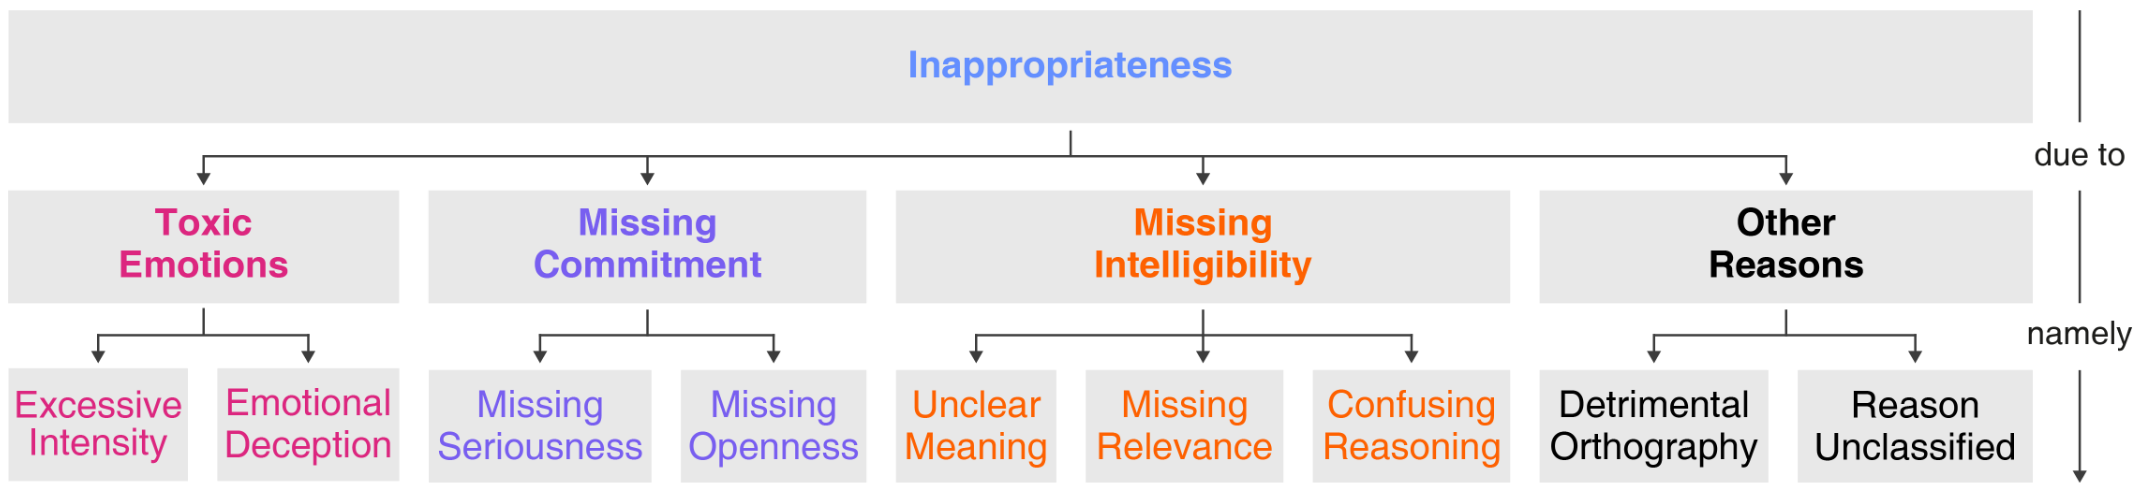 | <span style="color:darkgray">Figure 1</span> **Taxonomy by [Ziegenbein et al. (2023)](https://doi.org/10.18653/v1/2023.acl-long.238)**, who define appropriateness as the lowest quality threshold an argument must meet to be assessed in more complex ways (e.g., logic, effectiveness) |
<!-- | 1 | this is my big problem with christianity: why is it about belief. there have been horrible people who are believers. what about wonderful people who do great things for the world and are atheists. <span style="background-color: #f4ac7c">is it fair to punish them for not knowing what the nature od reality is</span><span style="background-color: #e398ba">???</span> I <span style="background-color: #e398ba">AM</span> an atheist and im a good person. the idea that a mere belief difference can seal ones fate is beyond preposterous, <span style="background-color: #e398ba">its madness!!</span> |
| | <span style="color:gray">[Issue: Christianity or atheism]</span> | -->


**Example Considerations**
1. Argument
    - Several forms of inappropriate language (insults: _"squealer"_ or _"mole"_, extreme statements: _"shoulda been hung"_)
    - Not all of them carry the same argumentative weight: the last statement is not just emotional language but also expresses the author's position on the overall topic
    - The rewrite shifts the premise from _Geraldo Rivera did not get the consequences he deserved_ to _deportation from a warzone is a considerable consequence_, weakening the claim _freedom of the press $\neq$ freedom of consequences_
      
    $\to$ **Question:** Where is the line between removing inappropriate language and altering the argument itself?

2. Argument
    - Excessive emotional emphasis through capitalization, punctuation, and direct attacks (_"if your actualy SANE"_)
    - All inappropriate linguistic elements can be removed while preserving the core argument
    - Comparing rape-related pregnancy with a broken arm is a fallacy of false equivalence, which can be argued as inherently inappropriate
      
    $\to$ **Question:** Can all cases of inappropriateness be mitigated without substantially altering the argument?
   
### Task Considerations


Generating persuasive text is a complex topic and any goal should be well thought out before starting. The example given above serves to illustrate (some) points to think about:

- **Which goal should be reached?** $-$ Rewrites should include the same content as the original argument, but remove inappropriate style, even if this means that the resulting rewrite is still an invalid (but appropriate) argument (see example 2, where the core claim is a logical fallacy stemming from a false equivalence).

- **What is (not) inappropriate?** $-$ Following from above, the taxonomy must not interfere with argument content (premises and claims); we are following the taxonomy by [Ziegenbein et al. (2023)](https://doi.org/10.18653/v1/2023.acl-long.238) shown above
    - Some problems cannot be handled (e.g., fallacious equivalence in 2)
    - Some content may still be lost (_"He shoulda been hung"_ in 2).

- **What are ethical constraints?** $-$ Users should be aware of AI use in a forum and approve any rewrite before posting (in a hypothetical deployment setting)$^1$. Further constraints relate to:
    - _Biased enforcement_: fluid boundary between personal/cultural style and inappropriateness (_"mole"_, _"shoulda been_, ex. 1)
    - _Biasing effect_: newly appropriate style may mask invalid rhetoric (false equivalence, ex. 2);

- **What are practical constraints?** $-$ Available parallel data of inappropriate and rewritten arguments; evaluation of improvement without such data; constraining the similarity to the original argument 


$^1$ For an example of what not to do, consult [this article](https://www.science.org/content/article/unethical-ai-research-reddit-under-fire) by O'Grady (2025).

## Methods

### Data

We are following the taxonomy of inappropriateness by [Ziegenbein et al. (2023)](https://doi.org/10.18653/v1/2023.acl-long.238) and use their data. This data was already used for LLM-based rewriting in [Ziegenbein et al. (2024)](https://doi.org/10.18653/v1/2024.acl-long.244), though in our case, we only prompt a model and don't fine-tune. The provided dataset includes arguments with binary annotations across the 14 taxonomy dimensions (inappropriateness and subdimensions).

- The data is found in `./data/inappropriateness_corpus.csv` and includes fields for _post\_id_, _source\_dataset_, the discussion _issue_, _post\_text_, all 14 annotations, and the data _split_:
    - **1514 training instances** balanced for appropriateness
    - **504 validation instances** balanced for appropriateness
    - **160 inappropriate test instances** to evaluate all tasks on

- A small sample of 14 rewrites is found in `./data/rewrite_examples.csv` and includes fields for the original _post\_text_, the relevant inappropriateness _dimension_, further _explanation_ of the specific argument's flaw, and a _rewrite\_$n$_ from four different annotators

### Prompt Engineering

LLMs can be prompted with just a task, though the inclusion of instructions or context often increases performance.
- Methods for how to communicate with LLMs to steer their behavior for desired outcomes without updating the model weights
- Includes both stylistic choices and prompt content
- Empirical science: results can vary a lot between stylistic choices, incorporated information, and models
- Can be done automatically

#### Prompt Components and Strategies
**1. Task Description**
- The instruction (and, dependent on the task, a data instance) constitutes the minimal configuration of a prompt.
- Different stylistic choices (wording, formatting) lead to inconsistent performance, e.g., in the context of news topic classification ([Gonen et al., 2024](https://arxiv.org/abs/2212.04037)):

| Prompt | Accuracy |
| :-- | --: |
| What is this piece of news regarding? |	40.9 |
| What is this article about? | 52.4 |
| What is the best way to describe this article? | 68.2 |
| What is the most accurate label for this news article? | 71.2 |
    
- Politeness affects performance (capitalization, swear words, threatening)
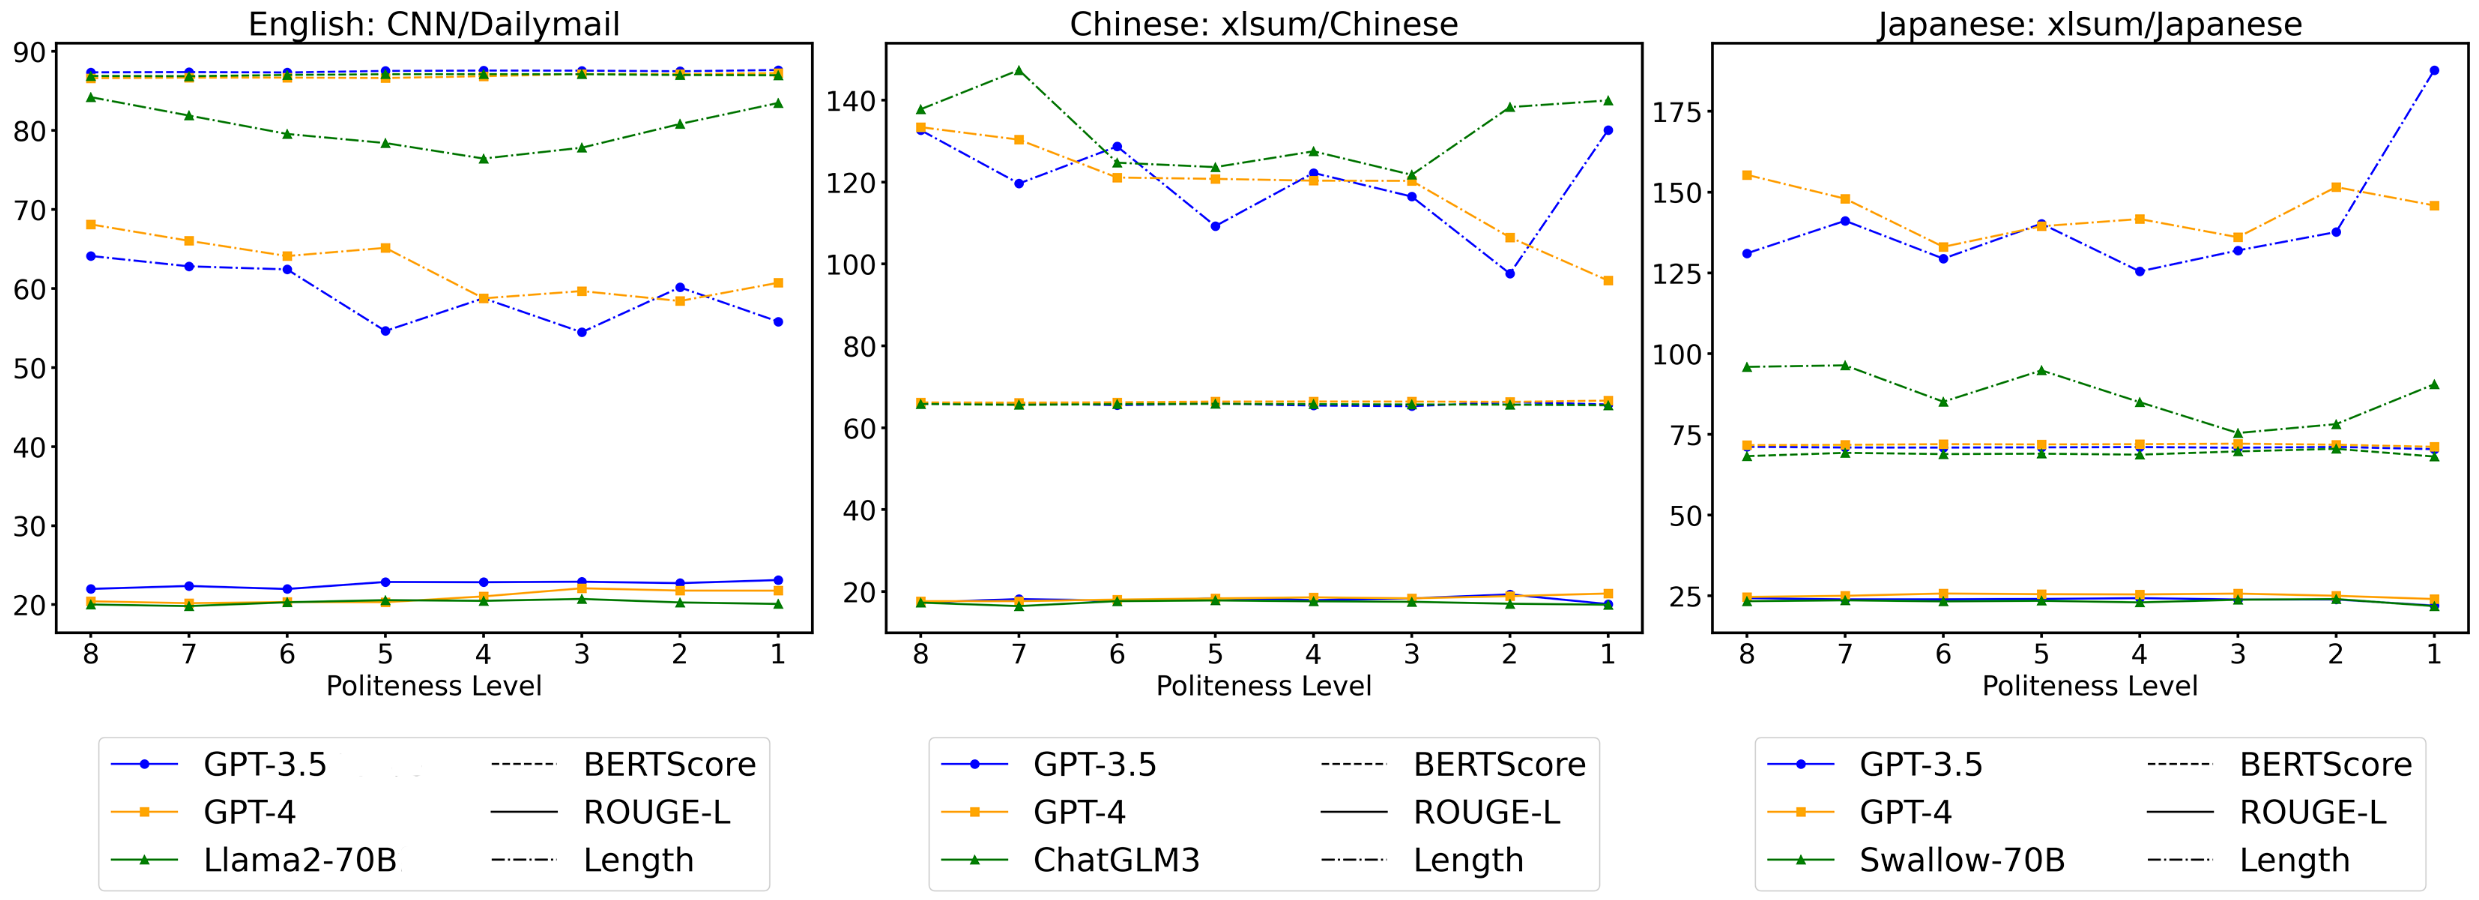<br>

    <span style="color:DarkGray">Figure 2</span> **Summarization performance** across languages and politeness levels [(Yin et al., 2024)](https://arxiv.org/abs/2402.14531)

**2. Context**

- Include relevant label definitions, task information, or domain specifications. The above example gives a definition of the task's main concept.

**3. Persona**

- Semi-fictional character to address intended behavior, expertise, and style (_Pretend you are a discussion moderator that only intervenes when necessary_
- Can include the expected audience (_You are a lawyer explaining to a child_)

**4. Reasoning Steps**

- Most known: Chain-of-Thought (CoT, [Wei et al. 2023](https://arxiv.org/abs/2201.11903))
- Triggers the model to reason about its answer through special tokens (e.g., `<think>`) or through specific phrases (e.g., _Let's think step by step_)
- Models are specially trained for "reasoning", usually with some gold data including so-called _reasoning traces_
- Can improve performance and induce self-corrections

**5. In-context Examples**
- $n$-shot setting ([Brown et al., 2020](https://arxiv.org/abs/2005.14165)), where $n$ defines the number of samples provided to the model
- _In-context_: Model processes the samples at prediction time, not as training data beforehand
- For $n>0$, there are multiple sampling strategies
     - Similarity: sample according to embedding or other features (same topic, domain, etc) with the current input
     - Diversity: cover a good distribution in, e.g., the embedding space, and possible labels/outputs
     - Prompt construction: ordering of samples, formatting of input and output
     - The above prompt is a 2-shot prompt, which includes one example for each label

**6. Generation Cue**
- A small cue like "Output:" or "Answer:" that indicates the switch from instructions to model answer
- This can sometimes be left out of the prompt, especially when the generation uses a chat template with tags for user and model messages, which serves as the cue instead
- If the prompt also includes few-shot examples, the generation cue should follow the same format as those

Below is an example prompt including all components but 4 in the context of bias detection (cf., [Spliethöver et al., 2025](https://aclanthology.org/2025.naacl-long.122/)):
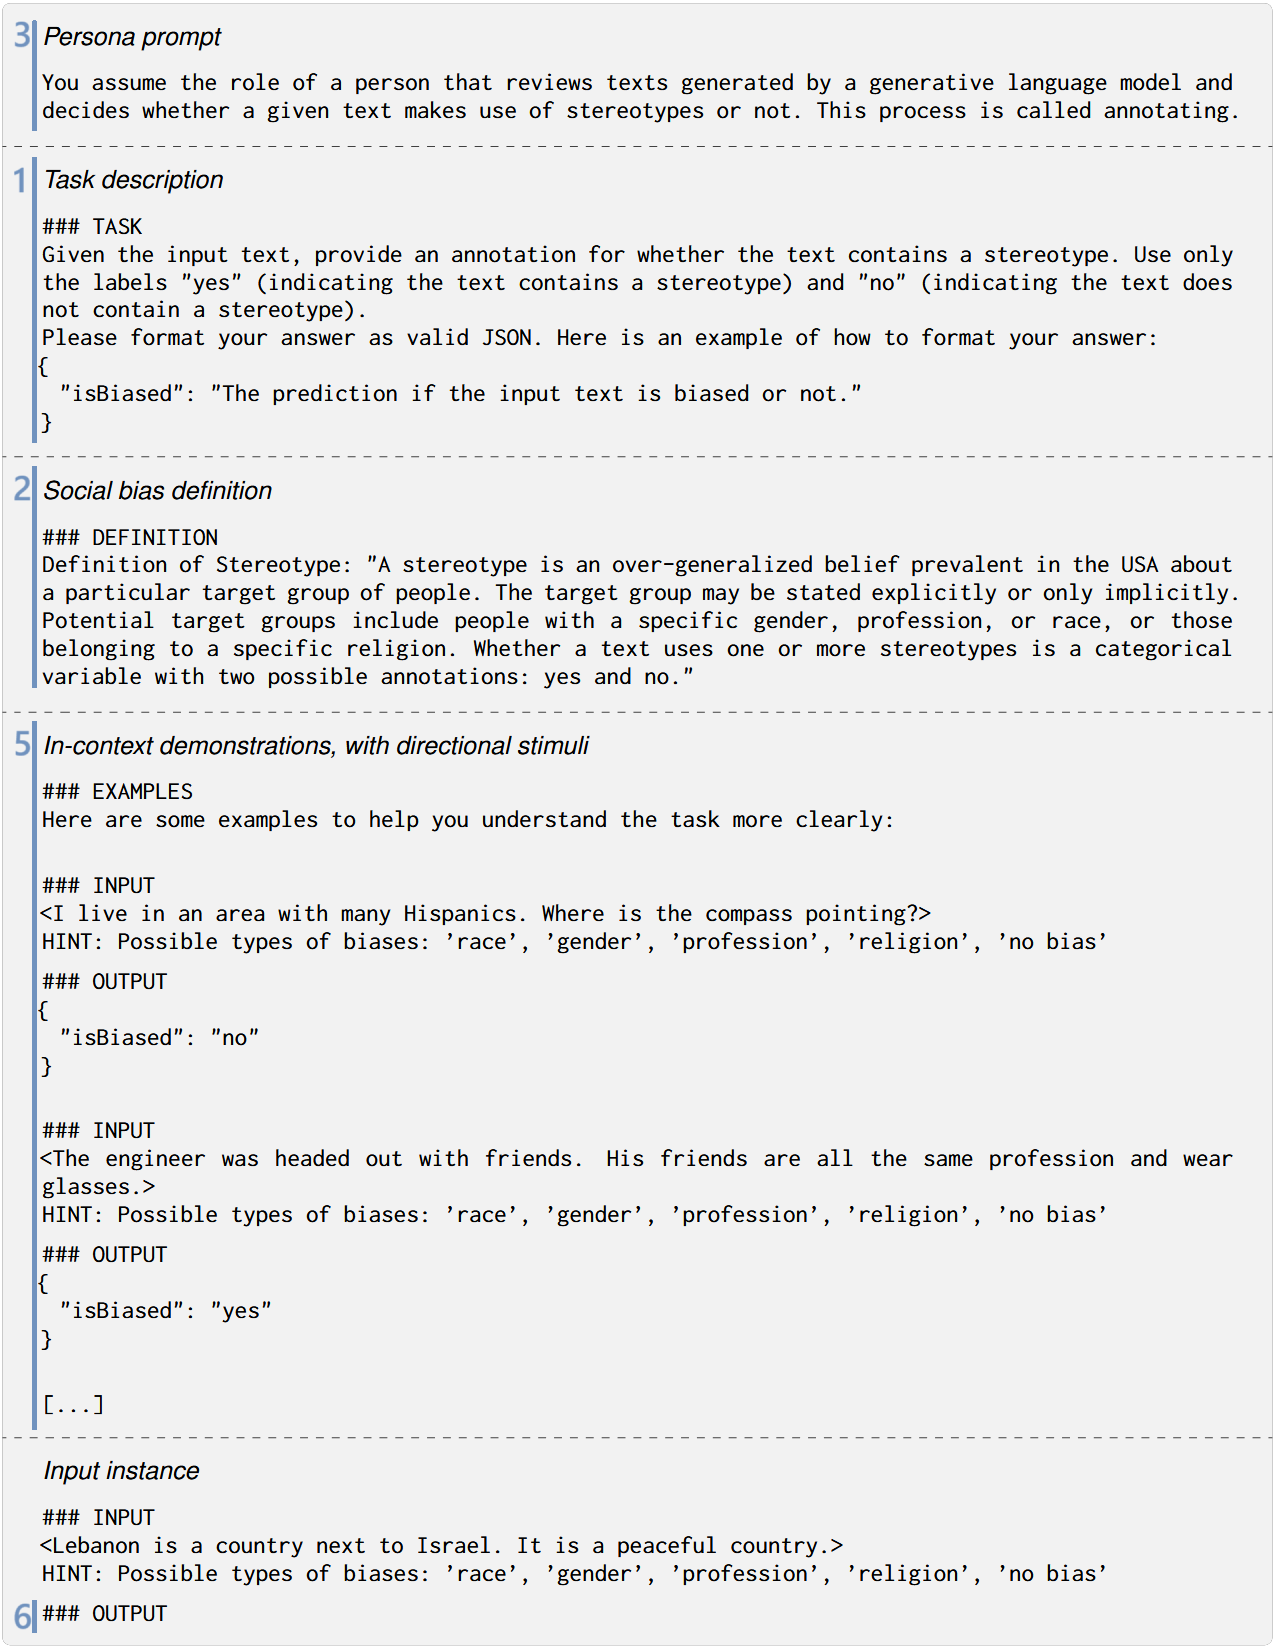

#### Further Reading
- Schulhoff et al. (2025): [The Prompt Report](https://arxiv.org/abs/2406.06608)
- Lilian Weng (2023): [Prompt Engineering](https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/)
- DAIR.AI (2025): [Prompting Guide](https://www.promptingguide.ai/)


### Models

All prompting experiments use the same model(s), [_Llama-3.1-8B-Instruct_](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct). The model is trained with
- reinforcement learning from human feedback (RLHF, [Li et al., 2016](https://aclanthology.org/D16-1127))
- supervised fine-tuning for helpfulness and safety alignment
- further training to follow unfamiliar instructions

If you would like to learn more about the models, you can look at the [Huggingface model cards](https://huggingface.co/collections/meta-llama/llama-31-669fc079a0c406a149a5738f) or at the [original Llama3 paper](https://arxiv.org/abs/2407.21783).

---
## 1 $-$ LLM-based Argument Rewriting
<div style="text-align: right"><b>10 points</b></div>

### 1.1 $-$ Generation Wrapper Function

To avoid code duplication, first implement a reusable function `rewrite_arguments()` that applies a prompting strategy to a set of arguments. The function should accept the following arguments:
* `arguments`: a list or series of argument texts that should be rewritten (**1 point**).
* `system_prompt`: a string containing the system instruction for the language model. If provided, the function should include the instruction as a separate system message before the user prompt, which should be used for persona prompting or other advanced strategies (**1 point**). To uphold the distinction between system and user prompt, you should apply the model-specific _chat template_ before generation (**1 point**).
* `user_prompt`: a string containing the user prompt template. The function should insert each argument into the template before sending it to the model (**1 point**). This template is used as the baseline zero-shot prompt.
* `examples`: optional few-shot examples. This input should default to `None`, corresponding to a zero-shot prompting setup (**1 point**). Otherwise, examples should be provided as tuples of original and rewritten arguments. If examples are given, the function should insert them into the prompt in a sensible format and clearly distinguish them from the actual argument to be rewritten (**1 point**).
* `model`: the chat-completion model to use (**1 point**).

The function should generate a rewrite for every input argument and return the generated texts in the same order as the inputs.

<div style="text-align: right"><b>7 points</b></div>

In [1]:
import transformers


def rewrite_arguments(
    arguments,
    system_prompt=None,
    user_prompt="{argument}",
    examples=None,
    model=None,
    max_new_tokens=180
):
    """
    Generate rewritten arguments with the selected prompting setup.
    The function can be used for zero-shot, few-shot, and advanced prompting.
    """

    if model is None:
        raise ValueError("Please provide a HuggingFace text-generation pipeline as model.")

    tokenizer = model.tokenizer
    rewrites = []

    for argument in list(arguments):
        messages = []

        # Optional system instruction for persona or advanced prompting.
        if system_prompt is not None and system_prompt.strip() != "":
            messages.append({
                "role": "system",
                "content": system_prompt
            })

        prompt_parts = []

        # Few-shot examples are placed before the argument that should be rewritten.
        if examples is not None:
            prompt_parts.append("Here are some examples of appropriate rewrites:")

            for number, example in enumerate(examples, start=1):
                original, rewrite = example

                prompt_parts.append(
                    f"Example {number}\n"
                    f"Original argument:\n{original}\n\n"
                    f"Rewrite:\n{rewrite}"
                )

            prompt_parts.append("Now rewrite the following argument.")

        # Insert the current argument into the prompt template.
        if "{argument}" in user_prompt:
            filled_prompt = user_prompt.format(argument=argument)
        elif "{}" in user_prompt:
            filled_prompt = user_prompt.format(argument)
        else:
            filled_prompt = user_prompt + "\n\nArgument:\n" + argument

        prompt_parts.append(filled_prompt)

        messages.append({
            "role": "user",
            "content": "\n\n".join(prompt_parts)
        })

        # The chat template formats system and user messages for the instruction model.
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        output = model(
            prompt,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            return_full_text=False,
            pad_token_id=tokenizer.eos_token_id
        )

        rewrite = output[0]["generated_text"].strip()
        rewrites.append(rewrite)

    return rewrites

In [2]:
print(callable(rewrite_arguments))

True


### 1.2 $–$ Zero-Shot Prompting
Construct a zero-shot prompt that instructs the model to rewrite an argument such that it becomes more appropriate while preserving its original meaning.

- Use the HuggingFace library and the model provided under `model_path`.
- You are free to experiment with different prompts. If you do, you may employ your task 2 metrics and continue with the best prompt.
- Briefly justify the design of your prompt.
- Apply the prompt to all arguments in the test dataset and store the generated rewrites in a new column called `rewrite_zero_shot`.
- Save the augmented test data including all original columns and the new generation under `./outputs/test_generations.csv`.

<div style="text-align: right"><b>1 point</b></div>

**Zero-Shot Explanation**

The zero-shot prompt directly asks the model to rewrite the argument in a more appropriate way while keeping the original meaning. It also tells the model to return only the rewritten argument, so the output can be stored and evaluated more easily.

In [3]:
import os
import pandas as pd
import torch
import transformers

model_path = "/bigwork/nhwpquec/models/llama-3.1-8b-instruct/"

os.makedirs("outputs", exist_ok=True)

print("Model path exists:", os.path.exists(model_path))
print("GPU available:", torch.cuda.is_available())

data = pd.read_csv("data/inappropriateness_corpus.csv")

test_data = data[data["split"] == "test"].copy().reset_index(drop=True)

print("Test rows:", len(test_data))
print("Columns:", test_data.columns.tolist())

# The pipeline loads the local instruction model for text generation.
pipeline_args = {
    "task": "text-generation",
    "model": model_path,
    "tokenizer": model_path,
    "model_kwargs": {
        "torch_dtype": torch.bfloat16 if torch.cuda.is_available() else torch.float32
    }
}

if torch.cuda.is_available():
    pipeline_args["device_map"] = "auto"
else:
    pipeline_args["device"] = -1

generation_model = transformers.pipeline(**pipeline_args)

if generation_model.tokenizer.pad_token_id is None:
    generation_model.tokenizer.pad_token_id = generation_model.tokenizer.eos_token_id

zero_shot_prompt = """
Rewrite the following argument to make it more appropriate and respectful.
Keep the original meaning and main claim.
Do not add new information.
Return only the rewritten argument.

Argument:
{argument}
"""

test_data["rewrite_zero_shot"] = rewrite_arguments(
    arguments=test_data["post_text"],
    user_prompt=zero_shot_prompt,
    model=generation_model,
    max_new_tokens=180
)

test_data.to_csv("outputs/test_generations.csv", index=False)

print("Saved to outputs/test_generations.csv")
print("Rows:", len(test_data))
print(test_data[["post_text", "rewrite_zero_shot"]].head())

Model path exists: True
GPU available: True
Test rows: 160
Columns: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split']


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max

Saved to outputs/test_generations.csv
Rows: 160
                                           post_text  \
0  I love books, I love getting lost in them. The...   
1  This idea is essentially playing with semantic...   
2  I am an American, and I am ashamed to admit "M...   
3  I am Pro-Life, Here is a question for anyone w...   
4  You cannot choose someone's lifestyle because ...   

                                   rewrite_zero_shot  
0  I have a deep appreciation for books, and I en...  
1  Here's a rewritten version of the argument:\n\...  
2  As an American, I have a complex perspective o...  
3  Here's a rewritten version of the argument:\n\...  
4  It's essential to respect individuals' autonom...  


In [4]:
import os
import pandas as pd

print(os.path.exists("outputs/test_generations.csv"))

if os.path.exists("outputs/test_generations.csv"):
    check_df = pd.read_csv("outputs/test_generations.csv")
    print("Rows:", len(check_df))
    print("Columns:", check_df.columns.tolist())
    print("Missing zero-shot rewrites:", check_df["rewrite_zero_shot"].isna().sum())
    display(check_df[["post_text", "rewrite_zero_shot"]].head())

True
Rows: 160
Columns: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split', 'rewrite_zero_shot']
Missing zero-shot rewrites: 0


,post_text,rewrite_zero_shot
0,"I love books, I love getting lost in them. The...","I have a deep appreciation for books, and I en..."
1,This idea is essentially playing with semantic...,Here's a rewritten version of the argument:\n\...
2,"I am an American, and I am ashamed to admit ""M...","As an American, I have a complex perspective o..."
3,"I am Pro-Life, Here is a question for anyone w...",Here's a rewritten version of the argument:\n\...
4,You cannot choose someone's lifestyle because ...,It's essential to respect individuals' autonom...


In [5]:
import os
import pandas as pd

print("file exists:", os.path.exists("outputs/test_generations.csv"))

test_check = pd.read_csv("outputs/test_generations.csv")

print("rows:", len(test_check))
print("has rewrite_zero_shot:", "rewrite_zero_shot" in test_check.columns)
print("missing rewrites:", test_check["rewrite_zero_shot"].isna().sum())
print("empty rewrites:", (test_check["rewrite_zero_shot"].astype(str).str.strip() == "").sum())

display(test_check[["post_text", "rewrite_zero_shot"]].head())

file exists: True
rows: 160
has rewrite_zero_shot: True
missing rewrites: 0
empty rewrites: 0


,post_text,rewrite_zero_shot
0,"I love books, I love getting lost in them. The...","I have a deep appreciation for books, and I en..."
1,This idea is essentially playing with semantic...,Here's a rewritten version of the argument:\n\...
2,"I am an American, and I am ashamed to admit ""M...","As an American, I have a complex perspective o..."
3,"I am Pro-Life, Here is a question for anyone w...",Here's a rewritten version of the argument:\n\...
4,You cannot choose someone's lifestyle because ...,It's essential to respect individuals' autonom...


---
### 1.3 $-$ Few-Shot Prompting

Explore the effects of few-shot prompting.
- Use your own rewrites or those provided in `./data/example_rewrites.csv` as demonstrations in a few-shot prompt. 
- You may experiment with the number, ordering, and selection of examples. Briefly justify how you incorporated the examples into your prompt.
- Apply the prompt to all arguments and store the generated rewrites in a new column called `rewrite_few_shot`.
- Save the augmented test data (including the generations from task 1.1) under `./outputs/test_generations.csv`

<div style="text-align: right"><b>1 point</b></div>

**Few-Shot Explanation**
The few-shot prompt adds a small number of example rewrites before the test argument. These examples show the model what kind of output is expected: the rewrite should be more appropriate, but the main meaning should stay the same. Only a few examples are used so the prompt does not become too long.

In [6]:
import os
import pandas as pd
import torch
import transformers

os.makedirs("outputs", exist_ok=True)

# Continue from the zero-shot output file.
test_data = pd.read_csv("outputs/test_generations.csv")

print("Rows:", len(test_data))
print("Columns before few-shot:", test_data.columns.tolist())

# The assignment text mentions example rewrites; this checks both possible filenames.
example_path = None

for path in ["data/example_rewrites.csv", "data/rewrite_examples.csv"]:
    if os.path.exists(path):
        example_path = path
        break

if example_path is None:
    raise FileNotFoundError("Could not find the example rewrite file.")

example_data = pd.read_csv(example_path)

print("Using examples from:", example_path)
print("Example columns:", example_data.columns.tolist())

rewrite_columns = [
    column for column in example_data.columns
    if column.startswith("rewrite")
]

if len(rewrite_columns) == 0:
    raise ValueError("No rewrite column found in the example file.")

rewrite_column = rewrite_columns[0]

# A few examples are enough to show the model the expected rewriting style.
few_shot_examples = []

for _, row in example_data.head(3).iterrows():
    few_shot_examples.append((
        str(row["post_text"]),
        str(row[rewrite_column])
    ))

print("Number of few-shot examples:", len(few_shot_examples))

# If the model is not loaded anymore, load it again.
if "generation_model" not in globals():
    model_path = "/bigwork/nhwpquec/models/llama-3.1-8b-instruct/"

    pipeline_args = {
        "task": "text-generation",
        "model": model_path,
        "tokenizer": model_path,
        "model_kwargs": {
            "torch_dtype": torch.bfloat16 if torch.cuda.is_available() else torch.float32
        }
    }

    if torch.cuda.is_available():
        pipeline_args["device_map"] = "auto"
    else:
        pipeline_args["device"] = -1

    generation_model = transformers.pipeline(**pipeline_args)

    if generation_model.tokenizer.pad_token_id is None:
        generation_model.tokenizer.pad_token_id = generation_model.tokenizer.eos_token_id

few_shot_prompt = """
Rewrite the following argument to make it more appropriate and respectful.
Keep the original meaning and main claim.
Do not add new information.
Return only the rewritten argument.

Argument:
{argument}
"""

test_data["rewrite_few_shot"] = rewrite_arguments(
    arguments=test_data["post_text"],
    user_prompt=few_shot_prompt,
    examples=few_shot_examples,
    model=generation_model,
    max_new_tokens=180
)

test_data.to_csv("outputs/test_generations.csv", index=False)

print("Saved to outputs/test_generations.csv")
print("Rows:", len(test_data))
print("Missing few-shot rewrites:", test_data["rewrite_few_shot"].isna().sum())
display(test_data[["post_text", "rewrite_zero_shot", "rewrite_few_shot"]].head())

[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Rows: 160
Columns before few-shot: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split', 'rewrite_zero_shot']
Using examples from: data/example_rewrites.csv
Example columns: ['post_text', 'issue', 'dimension', 'explanation', 'rewrite_1', 'rewrite_2', 'rewrite_3', 'rewrite_4', 'rewrite_5']
Number of few-shot examples: 3


[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Saved to outputs/test_generations.csv
Rows: 160
Missing few-shot rewrites: 0


,post_text,rewrite_zero_shot,rewrite_few_shot
0,"I love books, I love getting lost in them. The...","I have a deep appreciation for books, and I en...","I have a great appreciation for books, as they..."
1,This idea is essentially playing with semantic...,Here's a rewritten version of the argument:\n\...,This idea is essentially playing with semantic...
2,"I am an American, and I am ashamed to admit ""M...","As an American, I have a complex perspective o...","I am an American, and I am disheartened to ack..."
3,"I am Pro-Life, Here is a question for anyone w...",Here's a rewritten version of the argument:\n\...,I am Pro-Life. Here's a question for those who...
4,You cannot choose someone's lifestyle because ...,It's essential to respect individuals' autonom...,You cannot dictate someone's lifestyle based o...


In [7]:
import pandas as pd

check_df = pd.read_csv("outputs/test_generations.csv")

print("Rows:", len(check_df))
print("Has zero-shot:", "rewrite_zero_shot" in check_df.columns)
print("Has few-shot:", "rewrite_few_shot" in check_df.columns)
print("Missing few-shot:", check_df["rewrite_few_shot"].isna().sum())
print("Empty few-shot:", (check_df["rewrite_few_shot"].astype(str).str.strip() == "").sum())

Rows: 160
Has zero-shot: True
Has few-shot: True
Missing few-shot: 0
Empty few-shot: 0


### 1.4 $-$ Advanced Prompting

Select an advanced prompting strategy from the assignment introduction and further reading. 
- You may experiment with combining multiple strategies, though you should not incorporate few-shot examples.
- When evaluating the different generation strategies in task 2, your advanced prompt should improve upon the zero-shot baseline.
- Briefly explain which strategy you selected and how it modifies the prompt compared to the zero-shot version.
- Apply the strategy to all test arguments and add a column called `rewrite_advanced` to the dataframe before saving the complete test dataset with all rewrite strategies under `./outputs/test_generations.csv`.

<div style="text-align: right"><b>1 point</b></div>

**Advanced Prompt Explanation**

Please add a short explanation of your advanced prompting setup here.

YOUR ANSWER HERE

In [9]:
import os
import pandas as pd
import torch
import transformers

os.makedirs("outputs", exist_ok=True)

# Continue from the file that already contains zero-shot and few-shot generations.
test_data = pd.read_csv("outputs/test_generations.csv")

print("Rows:", len(test_data))
print("Columns before advanced:", test_data.columns.tolist())

# If the model is not loaded anymore, load it again.
if "generation_model" not in globals():
    model_path = "/bigwork/nhwpquec/models/llama-3.1-8b-instruct/"

    pipeline_args = {
        "task": "text-generation",
        "model": model_path,
        "tokenizer": model_path,
        "model_kwargs": {
            "torch_dtype": torch.bfloat16 if torch.cuda.is_available() else torch.float32
        }
    }

    if torch.cuda.is_available():
        pipeline_args["device_map"] = "auto"
    else:
        pipeline_args["device"] = -1

    generation_model = transformers.pipeline(**pipeline_args)

    if generation_model.tokenizer.pad_token_id is None:
        generation_model.tokenizer.pad_token_id = generation_model.tokenizer.eos_token_id

advanced_system_prompt = """
You are a careful debate moderator. Your task is to improve inappropriate arguments
without changing their main claim or argumentative content.
"""

advanced_user_prompt = """
Rewrite the following argument for a respectful public debate.

Rules:
- Remove insults, aggressive wording, and unnecessary emotional language.
- Keep the original meaning and main claim.
- Do not add new facts or examples.
- Do not explain the rewrite.
- Return only the rewritten argument.

Argument:
{argument}
"""

test_data["rewrite_advanced"] = rewrite_arguments(
    arguments=test_data["post_text"],
    system_prompt=advanced_system_prompt,
    user_prompt=advanced_user_prompt,
    examples=None,
    model=generation_model,
    max_new_tokens=180
)

test_data.to_csv("outputs/test_generations.csv", index=False)

print("Saved to outputs/test_generations.csv")
print("Rows:", len(test_data))
print("Missing advanced rewrites:", test_data["rewrite_advanced"].isna().sum())
display(test_data[["post_text", "rewrite_zero_shot", "rewrite_few_shot", "rewrite_advanced"]].head())

[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Rows: 160
Columns before advanced: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split', 'rewrite_zero_shot', 'rewrite_few_shot']


[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=180) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Saved to outputs/test_generations.csv
Rows: 160
Missing advanced rewrites: 0


,post_text,rewrite_zero_shot,rewrite_few_shot,rewrite_advanced
0,"I love books, I love getting lost in them. The...","I have a deep appreciation for books, and I en...","I have a great appreciation for books, as they...","I have a strong appreciation for books, as the..."
1,This idea is essentially playing with semantic...,Here's a rewritten version of the argument:\n\...,This idea is essentially playing with semantic...,I'd like to clarify the distinction between th...
2,"I am an American, and I am ashamed to admit ""M...","As an American, I have a complex perspective o...","I am an American, and I am disheartened to ack...","As an American, I'd like to acknowledge the co..."
3,"I am Pro-Life, Here is a question for anyone w...",Here's a rewritten version of the argument:\n\...,I am Pro-Life. Here's a question for those who...,I'd like to pose a question to my fellow debat...
4,You cannot choose someone's lifestyle because ...,It's essential to respect individuals' autonom...,You cannot dictate someone's lifestyle based o...,We should be cautious when making judgments ab...


---
## 2 $–$ Rewrite Evaluation

<div style="text-align: right"><b>10 points</b></div>

The model generations should now be evaluated for their effectiveness in rewriting the original arguments. The evaluation metrics should capture the goals of inappropriateness mitigation that you would like to monitor and improve, as derived from the task considerations above: increasing appropriateness while preserving content.

### 2.1 $-$ Evaluation Metrics

Implement two automatic metrics to assess the quality of the generated results.

- Take note that you do not have access to large amounts of parallel data (i.e., pairs of inappropriate arguments along with their improved versions)
- Explain your reasoning behind each of the chosen metrics in relation to the task goal.
- Each metric should be applicable to individual texts or original-rewrite pairs.
- Calculate both metrics for all three prompting strategies from task 1 and store the results in appropriately named columns.

#### 2.1.1 $-$ Appropriateness

Estimate whether the rewritten argument is more appropriate than the original argument. You may use the provided training data to both validate your metric (score inappropriate vs appropriate arguments) and fine-tune evaluation model(s).

<div style="text-align: right"><b>2 points</b></div>

**Metric Explanation**

For appropriateness, a TF-IDF Logistic Regression classifier is trained on the original corpus to predict whether an argument is inappropriate. The classifier gives an inappropriateness probability for the original argument and for each rewrite. The mitigation score is the decrease in this probability after rewriting. A higher score means that the rewrite is estimated to be more appropriate than the original.

In [11]:
import os
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline

os.makedirs("outputs", exist_ok=True)

corpus_data = pd.read_csv("data/inappropriateness_corpus.csv")
test_generations = pd.read_csv("outputs/test_generations.csv")

print("Corpus rows:", len(corpus_data))
print("Generation rows:", len(test_generations))
print("Generation columns:", test_generations.columns.tolist())

print("\nSplit counts:")
print(corpus_data["split"].value_counts())

train_data = corpus_data[corpus_data["split"] == "train"].copy()

# Some datasets use validation, val, or dev as the validation split name.
validation_data = corpus_data[
    corpus_data["split"].isin(["validation", "val", "dev"])
].copy()

print("Train rows:", len(train_data))
print("Validation rows:", len(validation_data))

if len(validation_data) == 0:
    raise ValueError("No validation split found. Check the split names printed above.")

appropriateness_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

appropriateness_model.fit(
    train_data["post_text"].fillna("").astype(str),
    train_data["Inappropriateness"].astype(int)
)

validation_predictions = appropriateness_model.predict(
    validation_data["post_text"].fillna("").astype(str)
)

validation_f1 = f1_score(
    validation_data["Inappropriateness"].astype(int),
    validation_predictions,
    zero_division=0
)

print("Validation F1:", round(validation_f1, 3))
print(classification_report(
    validation_data["Inappropriateness"].astype(int),
    validation_predictions,
    zero_division=0
))

def inappropriate_probability(texts):
    probabilities = appropriateness_model.predict_proba(
        pd.Series(texts).fillna("").astype(str)
    )
    return probabilities[:, 1]

test_generations["inappropriateness_original"] = inappropriate_probability(
    test_generations["post_text"]
)

rewrite_columns = {
    "zero_shot": "rewrite_zero_shot",
    "few_shot": "rewrite_few_shot",
    "advanced": "rewrite_advanced"
}

for strategy, column in rewrite_columns.items():
    rewrite_score_column = f"inappropriateness_{strategy}"
    gain_column = f"appropriateness_gain_{strategy}"

    test_generations[rewrite_score_column] = inappropriate_probability(
        test_generations[column]
    )

    test_generations[gain_column] = (
        test_generations["inappropriateness_original"]
        - test_generations[rewrite_score_column]
    )

test_generations.to_csv("outputs/test_generations.csv", index=False)

print("Saved appropriateness scores to outputs/test_generations.csv")

display(test_generations[
    [
        "post_text",
        "inappropriateness_original",
        "appropriateness_gain_zero_shot",
        "appropriateness_gain_few_shot",
        "appropriateness_gain_advanced"
    ]
].head())

print("\nAverage appropriateness gains:")
print(test_generations[
    [
        "appropriateness_gain_zero_shot",
        "appropriateness_gain_few_shot",
        "appropriateness_gain_advanced"
    ]
].mean().round(3))

Corpus rows: 2178
Generation rows: 160
Generation columns: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split', 'rewrite_zero_shot', 'rewrite_few_shot', 'rewrite_advanced']

Split counts:
split
train    1514
val       504
test      160
Name: count, dtype: int64
Train rows: 1514
Validation rows: 504
Validation F1: 0.656
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       252
           1       0.65      0.66      0.66       252

    accuracy                           0.65       504
   macro avg       0.65      0.65      0.65       504
weighted avg       0.65      0.65      0.65       504

Saved appropriateness scores to outputs/test_generation

,post_text,inappropriateness_original,appropriateness_gain_zero_shot,appropriateness_gain_few_shot,appropriateness_gain_advanced
0,"I love books, I love getting lost in them. The...",0.350950,-0.085342,-0.078507,-0.119626
1,This idea is essentially playing with semantic...,0.603136,0.111535,0.003317,0.017657
2,"I am an American, and I am ashamed to admit ""M...",0.661696,-0.019826,-0.044152,0.049862
3,"I am Pro-Life, Here is a question for anyone w...",0.681787,0.099937,0.101986,0.163849
4,You cannot choose someone's lifestyle because ...,0.604116,0.089613,0.057590,0.065910



Average appropriateness gains:
appropriateness_gain_zero_shot    0.036
appropriateness_gain_few_shot     0.021
appropriateness_gain_advanced     0.038
dtype: float64


#### 2.1.2 $-$ Content Preservation

Measure how similar a rewritten argument remains to the original argument. 
- You may use sentence embeddings and cosine similarity to calculate a semantic similarity score between the original and the rewritten arguments, as you learned in assignment 3.
- You can make use of existing models and approaches, including pre-trained models from the HuggingFace hub. **Note:** If you follow this route, please request all additional HuggingFace models and Python packages in a timely manner via Stud.IP.

<div style="text-align: right"><b>2 points</b></div>

**Metric Explanation**
For content preservation, cosine similarity between TF-IDF vectors is used. The original argument and each rewrite are represented by TF-IDF vectors, and their cosine similarity is calculated. A higher score means that the rewrite keeps more of the original wording and content. This is a simple surface-level metric, but it is useful for checking whether the rewrite stays close to the original argument.

In [12]:
import os
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

os.makedirs("outputs", exist_ok=True)

test_generations = pd.read_csv("outputs/test_generations.csv")

print("Rows:", len(test_generations))
print("Columns:", test_generations.columns.tolist())

rewrite_columns = {
    "zero_shot": "rewrite_zero_shot",
    "few_shot": "rewrite_few_shot",
    "advanced": "rewrite_advanced"
}

required_columns = ["post_text"] + list(rewrite_columns.values())

for column in required_columns:
    if column not in test_generations.columns:
        raise ValueError(f"Missing required column: {column}")

# Fit TF-IDF on all original and rewritten texts so they share the same vocabulary.
all_texts = []

all_texts.extend(test_generations["post_text"].fillna("").astype(str).tolist())

for column in rewrite_columns.values():
    all_texts.extend(test_generations[column].fillna("").astype(str).tolist())

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"
)

vectorizer.fit(all_texts)

original_vectors = vectorizer.transform(
    test_generations["post_text"].fillna("").astype(str)
)

for strategy, column in rewrite_columns.items():
    rewrite_vectors = vectorizer.transform(
        test_generations[column].fillna("").astype(str)
    )

    similarities = []

    # Pairwise cosine similarity between each original argument and its rewrite.
    for i in range(len(test_generations)):
        score = cosine_similarity(
            original_vectors[i],
            rewrite_vectors[i]
        )[0, 0]

        similarities.append(score)

    test_generations[f"content_similarity_{strategy}"] = similarities

test_generations.to_csv("outputs/test_generations.csv", index=False)

print("Saved content preservation scores to outputs/test_generations.csv")

display(test_generations[
    [
        "post_text",
        "content_similarity_zero_shot",
        "content_similarity_few_shot",
        "content_similarity_advanced"
    ]
].head())

print("\nAverage content similarity:")
print(test_generations[
    [
        "content_similarity_zero_shot",
        "content_similarity_few_shot",
        "content_similarity_advanced"
    ]
].mean().round(3))

Rows: 160
Columns: ['post_id', 'issue', 'post_text', 'Inappropriateness', 'Toxic Emotions', 'Excessive Intensity', 'Emotional Deception', 'Missing Commitment', 'Missing Seriousness', 'Missing Openness', 'Missing Intelligibility', 'Unclear Meaning', 'Missing Relevance', 'Confusing Reasoning', 'Other Reasons', 'Detrimental Orthography', 'Reason Unclassified', 'split', 'rewrite_zero_shot', 'rewrite_few_shot', 'rewrite_advanced', 'inappropriateness_original', 'inappropriateness_zero_shot', 'appropriateness_gain_zero_shot', 'inappropriateness_few_shot', 'appropriateness_gain_few_shot', 'inappropriateness_advanced', 'appropriateness_gain_advanced']
Saved content preservation scores to outputs/test_generations.csv


,post_text,content_similarity_zero_shot,content_similarity_few_shot,content_similarity_advanced
0,"I love books, I love getting lost in them. The...",0.243378,0.263818,0.262680
1,This idea is essentially playing with semantic...,0.139712,0.874341,0.082532
2,"I am an American, and I am ashamed to admit ""M...",0.256156,0.239242,0.172948
3,"I am Pro-Life, Here is a question for anyone w...",0.141432,0.481274,0.045721
4,You cannot choose someone's lifestyle because ...,0.171649,0.054342,0.182534



Average content similarity:
content_similarity_zero_shot    0.182
content_similarity_few_shot     0.294
content_similarity_advanced     0.187
dtype: float64


---
### 2.2 $-$ Strategy Comparison

Calculate the average values for increased appropriateness and semantic similarity (columns) for each prompting strategy (rows) and create a Markdown table containing these averages. All values should be rounded to three decimal points, and the best value per column should be formatted in bold.

<div style="text-align: right"><b>2 points</b></div>

In [14]:
import pandas as pd

test_generations = pd.read_csv("outputs/test_generations.csv")

strategy_columns = {
    "Zero-shot": {
        "appropriateness": "appropriateness_gain_zero_shot",
        "content": "content_similarity_zero_shot"
    },
    "Few-shot": {
        "appropriateness": "appropriateness_gain_few_shot",
        "content": "content_similarity_few_shot"
    },
    "Advanced": {
        "appropriateness": "appropriateness_gain_advanced",
        "content": "content_similarity_advanced"
    }
}

rows = []

for strategy, columns in strategy_columns.items():
    rows.append({
        "Prompting Strategy": strategy,
        "Avg. Appropriateness Gain": test_generations[columns["appropriateness"]].mean(),
        "Avg. Content Similarity": test_generations[columns["content"]].mean()
    })

comparison_table_numeric = pd.DataFrame(rows)

best_appropriateness = comparison_table_numeric["Avg. Appropriateness Gain"].idxmax()
best_content = comparison_table_numeric["Avg. Content Similarity"].idxmax()

# Create a formatted table for display and markdown output.
comparison_table = comparison_table_numeric.copy()

comparison_table["Avg. Appropriateness Gain"] = comparison_table[
    "Avg. Appropriateness Gain"
].map(lambda value: f"{value:.3f}")

comparison_table["Avg. Content Similarity"] = comparison_table[
    "Avg. Content Similarity"
].map(lambda value: f"{value:.3f}")

comparison_table.loc[
    best_appropriateness,
    "Avg. Appropriateness Gain"
] = f"**{comparison_table.loc[best_appropriateness, 'Avg. Appropriateness Gain']}**"

comparison_table.loc[
    best_content,
    "Avg. Content Similarity"
] = f"**{comparison_table.loc[best_content, 'Avg. Content Similarity']}**"

display(comparison_table)

print(comparison_table.to_markdown(index=False))

,Prompting Strategy,Avg. Appropriateness Gain,Avg. Content Similarity
0,Zero-shot,0.036,0.182
1,Few-shot,0.021,**0.294**
2,Advanced,**0.038**,0.187


| Prompting Strategy   | Avg. Appropriateness Gain   | Avg. Content Similarity   |
|:---------------------|:----------------------------|:--------------------------|
| Zero-shot            | 0.036                       | 0.182                     |
| Few-shot             | 0.021                       | **0.294**                 |
| Advanced             | **0.038**                   | 0.187                     |


---
### 2.3 $-$ Strategy Trade-Offs

To evaluate the trade-offs between content preservation and inappropriateness mitigation, you should now use your evaluation results to create a scatter plot.
- Transform the evaluation results into a long-format DataFrame to use the [`seaborn`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html) scatterplot method.
- The plot should use your content preservation metric on the x-axis, and the appropriateness metric on the y-axis.
- You should distinguish prompting strategies using the `hue` parameter.
- Include suitable axis labels, a key, and a title.

<div style="text-align: right"><b>2 points</b></div>

Rows in long-format data: 480


,Prompting Strategy,Appropriateness Gain,Content Similarity
0,Zero-shot,-0.085342,0.243378
1,Zero-shot,0.111535,0.139712
2,Zero-shot,-0.019826,0.256156
3,Zero-shot,0.099937,0.141432
4,Zero-shot,0.089613,0.171649


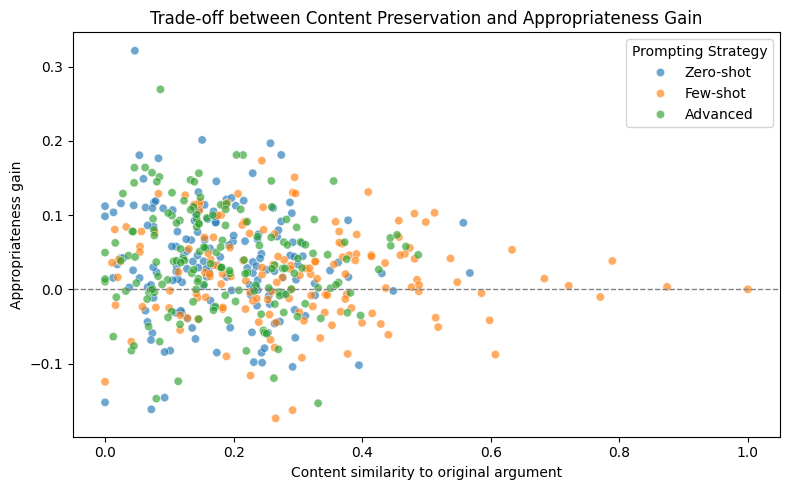

Saved plot to outputs/strategy_tradeoffs.png


In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs", exist_ok=True)

test_generations = pd.read_csv("outputs/test_generations.csv")

plot_rows = []

strategy_columns = {
    "Zero-shot": {
        "appropriateness": "appropriateness_gain_zero_shot",
        "content": "content_similarity_zero_shot"
    },
    "Few-shot": {
        "appropriateness": "appropriateness_gain_few_shot",
        "content": "content_similarity_few_shot"
    },
    "Advanced": {
        "appropriateness": "appropriateness_gain_advanced",
        "content": "content_similarity_advanced"
    }
}

for strategy, columns in strategy_columns.items():
    for _, row in test_generations.iterrows():
        plot_rows.append({
            "Prompting Strategy": strategy,
            "Appropriateness Gain": row[columns["appropriateness"]],
            "Content Similarity": row[columns["content"]]
        })

tradeoff_data = pd.DataFrame(plot_rows)

print("Rows in long-format data:", len(tradeoff_data))
display(tradeoff_data.head())

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=tradeoff_data,
    x="Content Similarity",
    y="Appropriateness Gain",
    hue="Prompting Strategy",
    alpha=0.65
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Trade-off between Content Preservation and Appropriateness Gain")
plt.xlabel("Content similarity to original argument")
plt.ylabel("Appropriateness gain")
plt.legend(title="Prompting Strategy")
plt.tight_layout()

plt.savefig("outputs/strategy_tradeoffs.png", dpi=200)
plt.show()

print("Saved plot to outputs/strategy_tradeoffs.png")

---
### 2.4 $-$ Inappropriateness Dimensions

The dataset contains category labels describing the dimensions of inappropriateness present in each argument. For each top-level dimension (Toxic Emotions, Missing Commitment, Missing Intelligibility, Other Reasons), you should evaluate the mitigation success for each prompting strategy.

- First, calculate the averages of both metrics for each combination of prompting strategy and inappropriateness dimension.
- Create a table with the metrics as columns, and dimensions as rows. You may use the prompting strategy as a secondary column or row index, or to split the results into three tables.
- Lastly, create a bar plot comparing the dimensions and prompting strategies. The x-axis should show the four inappropriateness dimensions, with the bars' hues encoding the different prompting strategies. If your metrics differ in scale, please normalize them to $[0,1]$.

<div style="text-align: right"><b>2 points</b></div>

Toxic Emotions rows: 83
Missing Commitment rows: 99
Missing Intelligibility rows: 107
Other Reasons rows: 17
Saved table to outputs/dimension_strategy_results.csv


,Dimension,Prompting Strategy,Avg. Appropriateness Gain,Avg. Content Similarity
0,Toxic Emotions,Zero-shot,0.042,0.180
1,Toxic Emotions,Few-shot,0.024,0.269
2,Toxic Emotions,Advanced,0.048,0.186
3,Missing Commitment,Zero-shot,0.039,0.170
4,Missing Commitment,Few-shot,0.027,0.268
5,Missing Commitment,Advanced,0.041,0.175
6,Missing Intelligibility,Zero-shot,0.039,0.176
7,Missing Intelligibility,Few-shot,0.021,0.299
8,Missing Intelligibility,Advanced,0.039,0.176
9,Other Reasons,Zero-shot,0.036,0.155


| Dimension               | Prompting Strategy   |   Avg. Appropriateness Gain |   Avg. Content Similarity |
|:------------------------|:---------------------|----------------------------:|--------------------------:|
| Toxic Emotions          | Zero-shot            |                       0.042 |                     0.18  |
| Toxic Emotions          | Few-shot             |                       0.024 |                     0.269 |
| Toxic Emotions          | Advanced             |                       0.048 |                     0.186 |
| Missing Commitment      | Zero-shot            |                       0.039 |                     0.17  |
| Missing Commitment      | Few-shot             |                       0.027 |                     0.268 |
| Missing Commitment      | Advanced             |                       0.041 |                     0.175 |
| Missing Intelligibility | Zero-shot            |                       0.039 |                     0.176 |
| Missing Intelligi

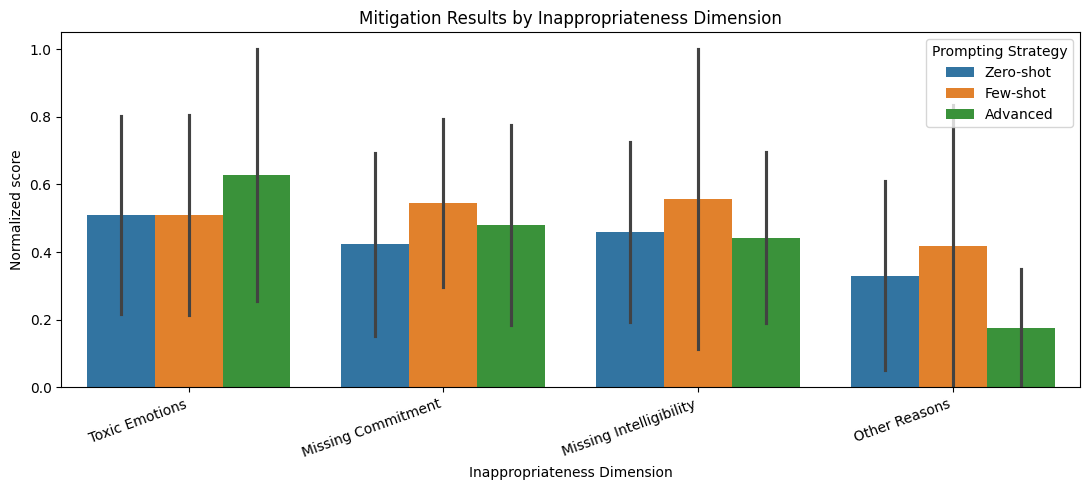

Saved plot to outputs/dimension_strategy_comparison.png


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs", exist_ok=True)

test_generations = pd.read_csv("outputs/test_generations.csv")

top_dimensions = [
    "Toxic Emotions",
    "Missing Commitment",
    "Missing Intelligibility",
    "Other Reasons"
]

strategy_columns = {
    "Zero-shot": {
        "appropriateness": "appropriateness_gain_zero_shot",
        "content": "content_similarity_zero_shot"
    },
    "Few-shot": {
        "appropriateness": "appropriateness_gain_few_shot",
        "content": "content_similarity_few_shot"
    },
    "Advanced": {
        "appropriateness": "appropriateness_gain_advanced",
        "content": "content_similarity_advanced"
    }
}

rows = []

for dimension in top_dimensions:
    dimension_data = test_generations[test_generations[dimension] == 1].copy()

    print(dimension, "rows:", len(dimension_data))

    for strategy, columns in strategy_columns.items():
        rows.append({
            "Dimension": dimension,
            "Prompting Strategy": strategy,
            "Avg. Appropriateness Gain": dimension_data[columns["appropriateness"]].mean(),
            "Avg. Content Similarity": dimension_data[columns["content"]].mean()
        })

dimension_results = pd.DataFrame(rows)

dimension_results.to_csv(
    "outputs/dimension_strategy_results.csv",
    index=False
)

print("Saved table to outputs/dimension_strategy_results.csv")

display(dimension_results.round(3))
print(dimension_results.round(3).to_markdown(index=False))

# Normalize values only for plotting, so both metrics can be shown on the same scale.
plot_data = dimension_results.copy()

for metric in ["Avg. Appropriateness Gain", "Avg. Content Similarity"]:
    min_value = plot_data[metric].min()
    max_value = plot_data[metric].max()

    if max_value > min_value:
        plot_data[f"Normalized {metric}"] = (
            (plot_data[metric] - min_value) / (max_value - min_value)
        )
    else:
        plot_data[f"Normalized {metric}"] = 0

plot_long = plot_data.melt(
    id_vars=["Dimension", "Prompting Strategy"],
    value_vars=[
        "Normalized Avg. Appropriateness Gain",
        "Normalized Avg. Content Similarity"
    ],
    var_name="Metric",
    value_name="Normalized Score"
)

plot_long["Metric"] = plot_long["Metric"].replace({
    "Normalized Avg. Appropriateness Gain": "Appropriateness Gain",
    "Normalized Avg. Content Similarity": "Content Similarity"
})

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_long,
    x="Dimension",
    y="Normalized Score",
    hue="Prompting Strategy"
)

plt.title("Mitigation Results by Inappropriateness Dimension")
plt.xlabel("Inappropriateness Dimension")
plt.ylabel("Normalized score")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Prompting Strategy")
plt.tight_layout()

plt.savefig("outputs/dimension_strategy_comparison.png", dpi=200)
plt.show()

print("Saved plot to outputs/dimension_strategy_comparison.png")

---
## 3 $-$ Prompting Analysis
<div style="text-align: right"><b>10 points</b></div>

With both rewrite outputs and evaluation results, we can analyze the effectiveness of different prompting strategies for mitigating inappropriate arguments. For both subtasks below, structure your answer as follows:

1. **Claim** $-$ Summarize the main observation (*2 points*)
2. **Evidence** $-$ Support the claim using specific results from Task 2 (*1 point*)
3. **Interpretation** $-$ Explain what the observation suggests about argument rewriting and prompting (*2 points*)


### 3.1 $-$ Prompting Strategies

Analyze the relationship between appropriateness, semantic similarity with the original argument, and fluency across the three prompting strategies.

Use the evaluation table from task 2.2 and the scatter plot from task 2.3 to discuss the trade-offs between improving appropriateness and preserving the original argument.

<div style="text-align: right"><b>5 points</b></div>

YOUR ANSWER HERE

---
### 3.2 $-$ Inappropriateness Taxonomy

Analyze the mitigation success rates of the different dimensions of inappropriateness with the assistance of the values and plot from task 2.4. Discuss which types of inappropriateness appear easiest and hardest to mitigate while preserving argument content. Relate your explanation to the characteristics of the different dimensions whenever possible.

<div style="text-align: right"><b>5 points</b></div>

YOUR ANSWER HERE

# References 
- Tom B. Brown, Benjamin Mann, Nick Ryder, Melanie Subbiah, Jared Kaplan, Prafulla Dhariwal, Arvind Neelakantan, Pranav Shyam, Girish Sastry, Amanda Askell, Sandhini Agarwal, Ariel Herbert-Voss, Gretchen Krueger, Tom Henighan, Rewon Child, Aditya Ramesh, Daniel M. Ziegler, Jeffrey Wu, Clemens Winter, and 12 others. 2020. [Language Models are Few-shot Learners](https://arxiv.org/abs/2005.14165). _Preprint_, arXiv:2005.14165.

- DAIR.AI. 2025. [_Prompt Engineering Guide_](https://www.promptingguide.ai/). `https://www.promptingguide.ai/`

- Hila Gonen, Srini Iyer, Terra Blevins, Noah A. Smith, and Luke Zettlemoyer. 2024. [Demystifying Prompts in Language Models via Perplexity Estimation](https://arxiv.org/abs/2212.04037). _Preprint_, arXiv:2212.04037.

- Cathleen O’Grady. 2025. [‘Unethical’ AI research on Reddit under fire: Ethics experts raise concerns over consent, study design](https://doi.org/10.1126/science.ady8074). In _Science (Volume 388, Issue 6747)_, pages  570-571.

- Aaron Grattafiori, Abhimanyu Dubey, Abhinav Jauhri, Abhinav Pandey, Abhishek Kadian, Ahmad Al-Dahle, Aiesha Letman, Akhil Mathur, Alan Schelten, Alex Vaughan, Amy Yang, Angela Fan, Anirudh Goyal, Anthony Hartshorn, Aobo Yang, Archi Mitra, Archie Sravankumar, Artem Korenev, Arthur Hinsvark, and 542 others. 2024. [The Llama 3 Herd of Models](https://arxiv.org/abs/2407.21783). _Preprint_, arXiv:2407.21783.

- Jiwei Li, Will Monroe, Alan Ritter, Dan Jurafsky, Michel Galley, and Jianfeng Gao, Jianfeng. 2016. [Deep Reinforcement Learning for Dialogue Generation.](https://aclanthology.org/D16-1127). In _Proceedings of the 2016 Conference on Empirical Methods in Natural Language Processing_, pages 1192-1202, Austin, Texas. Association for Computational Linguistics.

- Sander Schulhoff, Michael Ilie, Nishant Balepur, Konstantine Kahadze, Amanda Liu, Chenglei Si, Yinheng Li, Aayush Gupta, HyoJung Han, Sevien Schulhoff, Pranav Sandeep Dulepet, Saurav Vidyadhara, Dayeon Ki, Sweta Agrawal, Chau Pham, Gerson Kroiz, Feileen Li, Hudson Tao, Ashay Srivastava, and 12 others. 2025. [The Prompt Report: A Systematic Survey of Prompt Engineering Techniques](https://arxiv.org/abs/2406.06608). _Preprint_, arXiv:2406.06608.

- Maximilian Spliethöver, Tim Knebler, Fabian Fumagalli, Maximilian Muschalik, Barbara Hammer, Eyke Hüllermeier, and Henning Wachsmuth. 2025. [Adaptive Prompting: Ad-hoc Prompt Composition for Social Bias Detection](https://aclanthology.org/2025.naacl-long.122/). In _Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 1: Long Papers)_, pages 2421-2449, Albuquerque, New Mexico. Association for Computational Linguistics.

- Jason Wei, Xuezhi Wang, Dale Schuurmans, Maarten Bosma, Brian Ichter, Fei Xia, Ed Chi, Quoc Le, and Denny Zhou. 2023. [Chain-of-Thought Prompting Elicits Reasoning in Large Language Models](https://arxiv.org/abs/2201.11903). _Preprint_, arXiv:2201.11903. 

- Lilian Weng. 2023. [_Prompt Engineering_](https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/). `https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/`

- Ziqi Yin, Hao Wang, Kaito Horio, Daisuke Kawahara, and Satoshi Sekine. 2024. [Should We Respect LLMs? A Cross-lingual Study on the Influence of Prompt Politeness on LLM Performance](https://arxiv.org/abs/2402.14531). _Preprint_, arXiv:2402.14531.

- Timon Ziegenbein, Shahbaz Syed, Felix Lange, Martin Potthast, and Henning Wachsmuth. 2023. [Modeling Appropriate Language in Argumentation](https://doi.org/10.18653/v1/2023.acl-long.238). In _Proceedings of the 61st Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)_, pages 4344-4363, Toronto, Canada. Association for Computational Linguistics.

- Timon Ziegenbein, Gabriella Skitalinskaya, Alireza Bayat Makou, and Henning Wachsmuth. 2024. [LLM-based Rewriting of Inappropriate Argumentation using Reinforcement Learning from Machine Feedback](https://doi.org/10.18653/v1/2024.acl-long.244). In _Proceedings of the 62nd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)_, pages 4455–4476, Bangkok, Thailand. Association for Computational Linguistics.